# Tier 5 low-fidelity aerodynamics verification

Tier 5 adds a deliberately simple analytic aerodynamic model on the Tier 4
geometry (`aerodynamics/simple.py`):

* linear lift $C_L = C_{L\alpha}(\alpha - \alpha_{0L})$ with
  $C_{L\alpha} = 2\pi\,\text{CL\_over\_Cl}(AR, M)$ (AeroSandbox; Raymer 12.4.1 / DATCOM);
* parasite buildup $C_{D0} = \sum_i C_f(Re_i)\,FF_i\,Q_i\,S_{wet,i}/S_{ref} + CDA_{misc}/S_{ref}$
  with AeroSandbox skin friction and fuselage form factor and Raymer's surface
  form factor (eq. 12.30);
* induced drag $C_{Di} = C_L^2/(\pi e AR)$ with AeroSandbox's Oswald factor
  (Nita and Scholz);
* an additive `DragIncrement` hook for later contributions.

Wing lift only: tail lift and trim belong to Tier 6. The model replaces the
assumed cruise lift-to-drag in the mass closure with a cruise equilibrium solved
in the same Opti (`examples/cruise_closure.py`).

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier5_aerodynamics
```

In [1]:
import ast
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import DragIncrement, SimpleAerodynamics
from examples.aircraft_mass_closure import acceleration_gravity_m_s2, build_reference_aircraft, solve_mass_closure
from examples.cruise_closure import solve_cruise_closure

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


aircraft = build_reference_aircraft(3.23)
aero = SimpleAerodynamics()
velocity_m_s, altitude_m = 60.0, 1000.0
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Lift

The lift curve passes through zero at $\alpha_{0L}$ (-4 deg, an illustrative value
for a 4 %-cambered section), its slope is AeroSandbox's 3D ratio times $2\pi$,
below $2\pi$ and rising with aspect ratio, and the stall angle is where the
linear curve reaches $C_{L,max}$ (a caller-side bound; no post-stall model).

In [2]:
alpha_deg = np.linspace(-6, 16, 89)
cl = np.array([float(aero.evaluate(aircraft, velocity_m_s, altitude_m, a).cl) for a in alpha_deg])
slope = float(aero.lift_curve_slope_per_rad(aircraft, velocity_m_s, altitude_m))
alpha_stall_deg = float(aero.alpha_stall_deg(aircraft, velocity_m_s, altitude_m))
print(f"CL_alpha = {slope:.4f} /rad ({slope * np.pi / 180:.4f} /deg), stall at {alpha_stall_deg:.2f} deg")
check("lift: CL = 0 at the zero-lift angle", abs(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, -4.0).cl)) < 1e-12)
check("lift: constant slope (linear model)", np.ptp(np.diff(cl)) < 1e-12)
check("lift: 3D slope below 2 pi", slope < 2 * np.pi)
slopes = [float(aero.lift_curve_slope_per_rad(replace(aircraft, wing=replace(aircraft.wing, aspect_ratio=a)),
                                              velocity_m_s, altitude_m)) for a in (6, 9, 12)]
check("lift: slope rises with aspect ratio", slopes[0] < slopes[1] < slopes[2])
check("lift: CL at the stall angle equals CLmax",
      close(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_stall_deg).cl), aero.cl_max))

CL_alpha = 5.0230 /rad (0.0877 /deg), stall at 13.11 deg
PASS  lift: CL = 0 at the zero-lift angle
PASS  lift: constant slope (linear model)
PASS  lift: 3D slope below 2 pi
PASS  lift: slope rises with aspect ratio
PASS  lift: CL at the stall angle equals CLmax


## 2. Parasite drag buildup

Each component contributes $C_f\,FF\,Q\,S_{wet}/S_{ref}$ with its own Reynolds
number (MAC for surfaces, length for the fuselage). The miscellaneous drag area
(0.25 m2) stands for fixed gear, nacelles and stowed rotors, which this tier does
not model individually; it dominates $C_{D0}$, which is typical of fixed-gear
tiltrotor-like layouts but is an assumption, not a calibration.

wing            0.00980  (25.5 %)
horizontal_tail 0.00184  ( 4.8 %)
vertical_tail   0.00117  ( 3.1 %)
fuselage        0.00476  (12.4 %)
miscellaneous   0.02083  (54.2 %)
total           0.03840
PASS  parasite: CD0 equals the sum of the breakdown
PASS  parasite: miscellaneous item = CDA / S_ref
PASS  parasite: skin-friction terms fall with airspeed (Reynolds number)


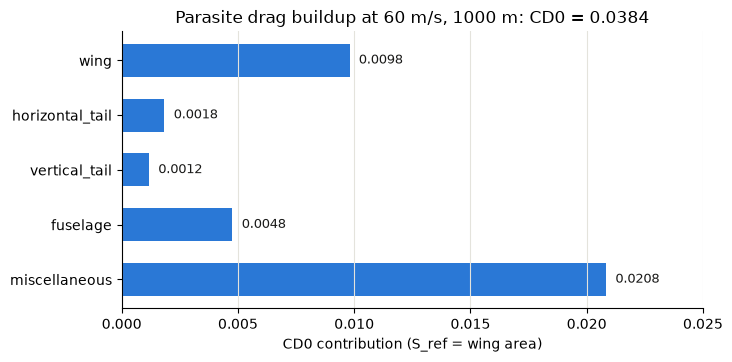

In [3]:
breakdown = aero.parasite_drag_breakdown(aircraft, velocity_m_s, altitude_m)
cd0 = sum(float(i.cd0) for i in breakdown)
for item in breakdown:
    print(f"{item.label:<16}{float(item.cd0):.5f}  ({100 * float(item.cd0) / cd0:4.1f} %)")
print(f"{'total':<16}{cd0:.5f}")
check("parasite: CD0 equals the sum of the breakdown",
      close(float(aero.evaluate(aircraft, velocity_m_s, altitude_m, 2.0).cd0), cd0))
check("parasite: miscellaneous item = CDA / S_ref", close(float(breakdown[-1].cd0), 0.25 / 12.0))
check("parasite: skin-friction terms fall with airspeed (Reynolds number)",
      float(aero.evaluate(aircraft, 80, altitude_m, 2.0).cd0) < float(aero.evaluate(aircraft, 40, altitude_m, 2.0).cd0))

labels = [i.label for i in breakdown][::-1]
values = [float(i.cd0) for i in breakdown][::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels, values, color=blue, height=0.6)
for y, v in enumerate(values):
    ax.text(v + 0.0004, y, f"{v:.4f}", va="center", fontsize=9, color=ink)
ax.set(xlabel="CD0 contribution (S_ref = wing area)", xlim=(0, max(values) * 1.2),
       title=f"Parasite drag buildup at {velocity_m_s:.0f} m/s, {altitude_m:.0f} m: CD0 = {cd0:.4f}")
ax.grid(axis="y", visible=False)
plt.show()

## 3. Drag polar and maximum lift-to-drag

With a parabolic polar, $C_D - C_{D0} = C_L^2/(\pi e AR)$ and the maximum
$L/D = \tfrac12\sqrt{\pi e AR / C_{D0}}$ occurs at $C_L^* = \sqrt{C_{D0}\pi e AR}$.

Oswald e = 0.7600, CL* = 0.9084, (L/D)max = 11.828
PASS  polar: CD - CD0 = CL^2 / (pi e AR)
PASS  polar: L/D at CL* equals the closed-form maximum
PASS  polar: L/D lower either side of CL*
PASS  hook: drag increments add to CD


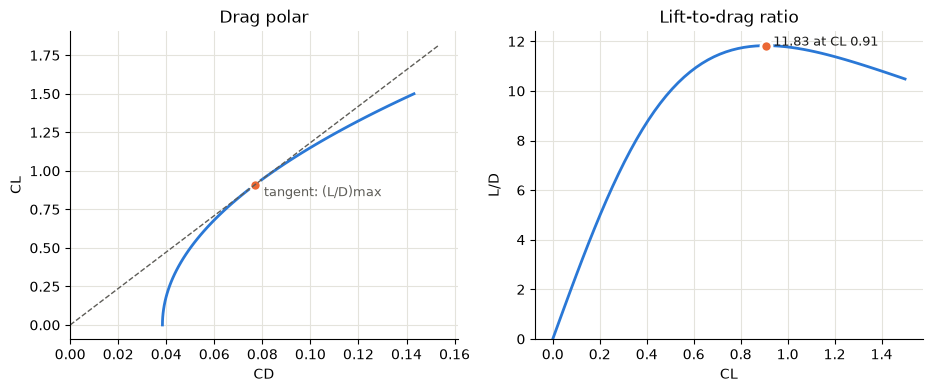

In [4]:
result = aero.evaluate(aircraft, velocity_m_s, altitude_m, 0.0)
cd0, e, aspect_ratio = float(result.cd0), float(result.oswald_efficiency), aircraft.wing.aspect_ratio
cl_star = np.sqrt(cd0 * np.pi * e * aspect_ratio)
lift_to_drag_max = 0.5 * np.sqrt(np.pi * e * aspect_ratio / cd0)
alpha_star_deg = aero.alpha_zero_lift_deg + np.degrees(cl_star / float(result.cl_alpha_per_rad))
best = aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_star_deg)
print(f"Oswald e = {e:.4f}, CL* = {cl_star:.4f}, (L/D)max = {lift_to_drag_max:.3f}")
check("polar: CD - CD0 = CL^2 / (pi e AR)", all(
    close(float(r.cd - r.cd0), float(r.cl**2 / (np.pi * e * aspect_ratio)))
    for r in (aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in (-2, 3, 8))))
check("polar: L/D at CL* equals the closed-form maximum", close(float(best.lift_to_drag), lift_to_drag_max, rel=1e-9))
check("polar: L/D lower either side of CL*", all(
    float(aero.evaluate(aircraft, velocity_m_s, altitude_m, alpha_star_deg + d).lift_to_drag) < lift_to_drag_max
    for d in (-1, 1)))
check("hook: drag increments add to CD", close(float(aero.evaluate(
    aircraft, velocity_m_s, altitude_m, 3.0, (DragIncrement("probe", 0.003),)).cd - aero.evaluate(
    aircraft, velocity_m_s, altitude_m, 3.0).cd), 0.003))

polar = [aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in np.linspace(-4, alpha_stall_deg, 60)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot([float(r.cd) for r in polar], [float(r.cl) for r in polar], color=blue, lw=2)
ax1.plot([float(best.cd)], [float(best.cl)], "o", color=orange, ms=8, mec="white", mew=2)
ax1.plot([0, 2 * float(best.cd)], [0, 2 * float(best.cl)], color=ink_muted, lw=1, ls="--")
ax1.text(float(best.cd) * 1.05, float(best.cl) * 0.92, "tangent: (L/D)max", color=ink_muted, fontsize=9)
ax1.set(xlabel="CD", ylabel="CL", xlim=(0, None), title="Drag polar")
ax2.plot([float(r.cl) for r in polar], [float(r.lift_to_drag) for r in polar], color=blue, lw=2)
ax2.plot([cl_star], [lift_to_drag_max], "o", color=orange, ms=8, mec="white", mew=2)
ax2.text(cl_star + 0.03, lift_to_drag_max, f"{lift_to_drag_max:.2f} at CL {cl_star:.2f}", fontsize=9, color=ink)
ax2.set(xlabel="CL", ylabel="L/D", ylim=(0, None), title="Lift-to-drag ratio")
plt.show()

## 4. Comparison with AeroSandbox `AeroBuildup`

`AeroBuildup` is AeroSandbox's higher-fidelity buildup on the same `asb.Airplane`.
It includes tail lift and its own drag submodels but not the miscellaneous drag
area, so agreement is expected in order of magnitude only. The comparison is
reported, not tuned: the simple model stays the simplest useful model, and
`AeroBuildup` is the natural next-fidelity source (architecture: intended aero
source 2).

In [5]:
alphas = np.array([0.0, 2.0, 4.0, 6.0])
ours = [aero.evaluate(aircraft, velocity_m_s, altitude_m, a) for a in alphas]
native = [asb.AeroBuildup(airplane=aircraft.to_asb(), op_point=asb.OperatingPoint(
    atmosphere=asb.Atmosphere(altitude=altitude_m), velocity=velocity_m_s, alpha=a)).run() for a in alphas]
slope_ours = float(np.polyfit(alphas, [float(r.cl) for r in ours], 1)[0])
slope_native = float(np.polyfit(alphas, [float(np.ravel(r["CL"])[0]) for r in native], 1)[0])
cd_native_0 = float(np.ravel(native[0]["CD"])[0])
print(f"lift slope per deg: simple {slope_ours:.4f}, AeroBuildup (with tails) {slope_native:.4f}")
print(f"CD at 0 deg: simple {float(ours[0].cd):.4f} (incl. misc {0.25 / 12:.4f}), AeroBuildup {cd_native_0:.4f}")
check("comparison: wing-only slope below AeroBuildup's whole-aircraft slope (tail lift is Tier 6)", slope_ours < slope_native)
check("comparison: slopes within 30 % (order agreement)", abs(slope_ours / slope_native - 1) < 0.30)
check("comparison: CD0 without misc area within a factor 2 of AeroBuildup",
      0.5 < (float(ours[0].cd) - 0.25 / 12) / cd_native_0 < 2.0)

lift slope per deg: simple 0.0877, AeroBuildup (with tails) 0.1052
CD at 0 deg: simple 0.0441 (incl. misc 0.0208), AeroBuildup 0.0235
PASS  comparison: wing-only slope below AeroBuildup's whole-aircraft slope (tail lift is Tier 6)
PASS  comparison: slopes within 30 % (order agreement)
PASS  comparison: CD0 without misc area within a factor 2 of AeroBuildup


## 5. Reference case: cruise equilibrium inside the mass closure

`solve_cruise_closure` adds the angle of attack as an Opti variable with
lift = weight at 60 m/s and 1000 m, and passes the resulting $L/D$ to the
structural design condition. The fuselage correlation depends on $L/D$ only
weakly ($^{-0.072}$), so MTOM moves by well under 1 %; the value of this tier is
that cruise drag and drag power now come from geometry. With the large
miscellaneous drag area the minimum-power lift coefficient exceeds CLmax, so
drag power rises monotonically from stall.

In [6]:
cruise = solve_cruise_closure()
assumed = solve_mass_closure()
print(cruise)
weight_N = cruise.mass_takeoff_kg * acceleration_gravity_m_s2
check("cruise: closure residual ~ 0", abs(cruise.closure_residual_kg) < 1e-6)
check("cruise: lift equals weight", abs(cruise.lift_residual_N) < 1e-6)
check("cruise: drag = W / (L/D)", close(cruise.drag_cruise_N, weight_N / cruise.lift_to_drag_cruise, rel=1e-9))
check("cruise: below stall", cruise.alpha_cruise_deg < cruise.alpha_stall_deg)
check("cruise: cruise L/D below (L/D)max", cruise.lift_to_drag_cruise <= lift_to_drag_max + 1e-9)
check("cruise: MTOM within 1 % of the assumed-L/D closure",
      abs(cruise.mass_takeoff_kg - assumed.mass_takeoff_kg) / assumed.mass_takeoff_kg < 0.01)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


CruiseClosureResult(mass_takeoff_kg=1552.9099607311284, x_le_wing_m=3.232609465990042, alpha_cruise_deg=3.2398355844216242, alpha_stall_deg=13.110023386385823, cl_cruise=0.634701258519224, cd_cruise=0.05714998319609596, cd0=0.03840353736555466, oswald_efficiency=0.7600241555585326, lift_to_drag_cruise=11.105887054094215, drag_cruise_N=1371.2407115458868, power_drag_cruise_W=82274.4426927532, closure_residual_kg=2.94903657049872e-10, lift_residual_N=4.82032191939652e-10, component_masses_kg=(('wing', 132.12778358866956), ('horizontal_tail', 11.919432799443786), ('vertical_tail', 8.899687984501087), ('fuselage', 83.68420426076263), ('landing_gear', 69.59217724571273), ('systems', 66.68667485174363), ('powertrain', 880.0), ('payload', 300.0)))
PASS  cruise: closure residual ~ 0
PASS  cruise: lift equals weight
PASS  cruise: drag = W / (L/D)
PASS  cruise: below stall
PASS  cruise: cruise L/D below (L/D)max
PASS  cruise: MTOM within 1 % of the assumed-L/D closure


stall speed 39.0 m/s; CL for minimum power 1.573 vs CLmax 1.5


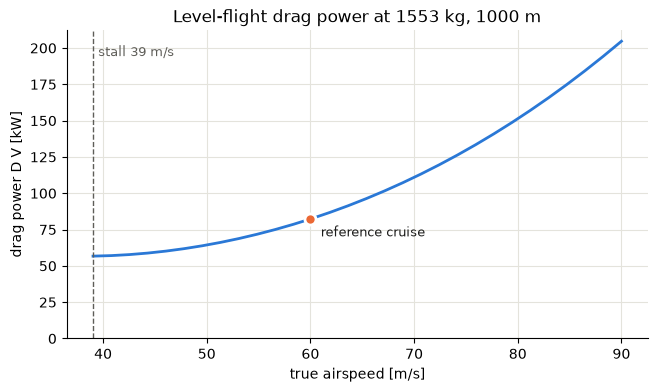

PASS  power curve: CL for minimum power exceeds CLmax, so minimum power sits at stall
PASS  power curve: drag power rises monotonically above stall
PASS  power curve: reference cruise point lies on the curve


In [7]:
# Drag power versus airspeed at the closed mass (level flight, wing lift = weight).
mass_kg = cruise.mass_takeoff_kg
stall_speed = float(np.sqrt(2 * mass_kg * acceleration_gravity_m_s2 / (
    asb.Atmosphere(altitude=altitude_m).density() * aircraft.wing.area_m2 * aero.cl_max)))
speeds = np.linspace(stall_speed, 90, 30)
power_kW = []
for v in speeds:
    opti = asb.Opti()
    alpha = opti.variable(init_guess=4)
    point = aero.evaluate(build_reference_aircraft(cruise.x_le_wing_m), v, altitude_m, alpha)
    opti.subject_to(point.lift_N == mass_kg * acceleration_gravity_m_s2)
    sol = opti.solve(verbose=False)
    power_kW.append(float(sol.value(point.drag_N)) * v / 1e3)
power_kW = np.array(power_kW)
# Parabolic polar: minimum drag power at CL = sqrt(3 CD0 pi e AR).
cl_min_power = np.sqrt(3 * cd0 * np.pi * e * aspect_ratio)
print(f"stall speed {stall_speed:.1f} m/s; CL for minimum power {cl_min_power:.3f} vs CLmax {aero.cl_max}")
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(speeds, power_kW, color=blue, lw=2)
ax.axvline(float(stall_speed), color=ink_muted, lw=1, ls="--")
ax.text(float(stall_speed) + 0.5, power_kW.max() * 0.95, f"stall {float(stall_speed):.0f} m/s", color=ink_muted, fontsize=9)
ax.plot([velocity_m_s], [cruise.power_drag_cruise_W / 1e3], "o", color=orange, ms=8, mec="white", mew=2)
ax.text(velocity_m_s + 1, cruise.power_drag_cruise_W / 1e3 - 12, "reference cruise", fontsize=9, color=ink)
ax.set(xlabel="true airspeed [m/s]", ylabel="drag power D V [kW]", ylim=(0, None),
       title=f"Level-flight drag power at {mass_kg:.0f} kg, {altitude_m:.0f} m")
plt.show()
check("power curve: CL for minimum power exceeds CLmax, so minimum power sits at stall",
      cl_min_power > aero.cl_max)
check("power curve: drag power rises monotonically above stall", np.all(np.diff(power_kW) > 0))
check("power curve: reference cruise point lies on the curve",
      close(float(np.interp(velocity_m_s, speeds, power_kW)), cruise.power_drag_cruise_W / 1e3, rel=1e-2))

## 6. Symbolic use and boundaries

Angle of attack and geometry may be Opti variables: maximizing $L/D$ over
$\alpha$ recovers the closed-form maximum. The aerodynamics package reads
geometry from component objects without importing the vehicle layer, and
references no Opti API.

In [8]:
opti = asb.Opti()
alpha = opti.variable(init_guess=2)
area_m2 = opti.variable(init_guess=10, lower_bound=1)
symbolic = aero.evaluate(replace(aircraft, wing=replace(aircraft.wing, area_m2=area_m2)), velocity_m_s, altitude_m, alpha)
check("symbolic: L/D with variable alpha and wing area is CasADi MX", isinstance(symbolic.lift_to_drag, cas.MX))
opti.subject_to(area_m2 == aircraft.wing.area_m2)
opti.minimize(-symbolic.lift_to_drag)
sol = opti.solve(verbose=False)
check("symbolic: optimizer recovers the closed-form (L/D)max",
      close(float(sol.value(symbolic.lift_to_drag)), lift_to_drag_max, rel=1e-6))

tree = ast.parse((repo_root / "src/aircraft_closure/aerodynamics/simple.py").read_text(encoding="utf-8"))
imports = {n.module for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
imports |= {a.name for n in ast.walk(tree) if isinstance(n, ast.Import) for a in n.names}
used = {n.id for n in ast.walk(tree) if isinstance(n, ast.Name)} | {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
check("boundaries: aerodynamics imports no vehicle or powertrain module",
      not any(("vehicle" in (m or "")) or ("powertrain" in (m or "")) for m in imports))
check("boundaries: aerodynamics references no Opti API",
      not used & {"Opti", "variable", "subject_to", "solve", "minimize", "parameter"})

PASS  symbolic: L/D with variable alpha and wing area is CasADi MX
PASS  symbolic: optimizer recovers the closed-form (L/D)max
PASS  boundaries: aerodynamics imports no vehicle or powertrain module
PASS  boundaries: aerodynamics references no Opti API


## 7. Summary and unit test suite

In [9]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

28 / 28 notebook checks passed


In [10]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 126 tests in 4.618s

OK
